# 📊 **Exploratory Data Analysis — ETH Price × BTC Cross-Features**

### 🎯 **Objective**
Assess whether **Bitcoin market features** add useful signal on top of ETH market features for ETH crash prediction.

### ⚠️ **Target Definition**
A crash is defined as a price drop of more than **10% within the next 7 days** — the same definition as in notebook 03 (ETH EDA).

- `True` → Crash
- `False` → No crash

### 🔬 **EDA Focus**
1. Merge ETH and BTC daily price datasets on date
2. Rename BTC columns with `_btc` suffix to avoid conflicts (BTC target is dropped)
3. Measure linear, monotonic, and non-linear dependencies of BTC features with the ETH target
4. Select BTC cross-features using a combined score (Spearman + MI)
5. Build a compact feature set for benchmarking

### 🚀 **Goal**
Determine whether **BTC market variables** bring complementary information for predicting ETH crashes. As the dominant asset, BTC price action often leads the broader market — the hypothesis is that BTC momentum or volatility signals may anticipate ETH reversals.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler

In [3]:
df_eth = pd.read_csv("../../data/gold/market/eth_usdt_1d_features.csv")
df_btc = pd.read_csv("../../data/gold/market/btc_usdt_1d_features.csv")

### 1. Initial Data Overview

In [4]:
df_btc.head()

,open_time,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,...,lag_volume_norm,lag_buy_pressure,momentum_acc,volatility_ratio,momentum_volatility,pressure_x_return,ma_7,ma_30,ma_ratio,target
0,2017-09-16,3674.01,3950.00,3470.66,3714.95,1297.563953,4.804878e+06,8809,624.887842,2.314536e+06,...,2.390714,0.490700,-0.156191,1.727747,-0.013297,0.001946,3864.460000,4239.663667,0.911502,1
1,2017-09-17,3685.23,3748.21,3499.02,3699.99,682.171210,2.466490e+06,6355,273.931976,9.948436e+05,...,1.544177,0.481585,-0.008068,1.737193,-0.010831,-0.001617,3802.977143,4226.051000,0.899889,1
2,2017-09-18,3690.00,4123.20,3690.00,4035.01,1030.006455,4.069033e+06,8220,417.638722,1.651863e+06,...,0.828846,0.401559,0.094573,1.780640,-0.004561,0.036714,3778.197143,4222.552000,0.894766,1
3,2017-09-19,4060.00,4089.97,3830.91,3910.04,902.332129,3.558315e+06,7342,257.320352,1.016804e+06,...,1.219432,0.405472,-0.121518,1.783364,-0.006777,-0.008832,3741.957143,4216.677000,0.887418,1
4,2017-09-20,3910.04,4046.08,3820.00,3900.00,720.935076,2.839584e+06,7231,395.275138,1.562210e+06,...,1.050238,0.285173,0.028404,1.752188,-0.001237,-0.001408,3735.572857,4212.810333,0.886718,0


In [5]:
print(f"{df_eth.shape[0]} rows and {df_eth.shape[1]} columns in the ETH price dataset.")
print(f"{df_btc.shape[0]} rows and {df_btc.shape[1]} columns in the BTC price dataset.")

3114 rows and 30 columns in the ETH price dataset.
3115 rows and 30 columns in the BTC price dataset.


**Observation:**
Both datasets share the same column structure and cover daily OHLCV + engineered features.
BTC columns will be renamed with the `_btc` suffix before merging so that only the ETH target is used as the prediction objective.

**Impact:**
The inner join on `open_time` will retain dates present in both datasets. Both cover approximately the same period (from 2017), so overlap should be nearly complete.

### 2. Time Alignment and Merge

In [6]:
df_eth["open_time"] = pd.to_datetime(df_eth["open_time"], errors="coerce")
df_btc["open_time"] = pd.to_datetime(df_btc["open_time"], errors="coerce")

print(f"ETH price range: {df_eth['open_time'].min().date()} to {df_eth['open_time'].max().date()}")
print(f"BTC price range: {df_btc['open_time'].min().date()} to {df_btc['open_time'].max().date()}")

ETH price range: 2017-09-16 to 2026-03-26
BTC price range: 2017-09-16 to 2026-03-27


**Observation:**
Both series use the same ISO date format — no offset correction is needed. The inner join will naturally restrict to the common window.

**Conclusion:**
Date alignment is straightforward. Any small discrepancy at the extremes will be handled by the inner join.

### 3. Merged ETH + BTC Cross Dataset

In [7]:
# Rename BTC columns with _btc suffix (except open_time used as join key)
btc_renamed = df_btc.rename(columns={c: f"{c}_btc" for c in df_btc.columns if c != "open_time"})

# Merge — inner join on open_time
df_merged = pd.merge(df_eth, btc_renamed, on="open_time", how="inner")

# Drop BTC target (not the prediction objective here)
df_merged.drop(columns=["target_btc", "open_time"], inplace=True)

print(f"Merged dataset: {df_merged.shape[0]} rows, {df_merged.shape[1]} columns")
df_merged.head()

Merged dataset: 3114 rows, 57 columns


,open,high,low,close,volume,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,return_1d,...,lag_volatility_7d_btc,lag_volume_norm_btc,lag_buy_pressure_btc,momentum_acc_btc,volatility_ratio_btc,momentum_volatility_btc,pressure_x_return_btc,ma_7_btc,ma_30_btc,ma_ratio_btc
0,255.99,271.81,235.51,249.31,10362.06011,2.647152e+06,8859,3866.60141,995005.326705,-0.014585,...,0.103904,2.390714,0.490700,-0.156191,1.727747,-0.013297,0.001946,3864.460000,4239.663667,0.911502
1,249.32,264.39,239.02,257.55,4614.53337,1.149704e+06,5277,1442.00382,360268.473861,0.033051,...,0.104128,1.544177,0.481585,-0.008068,1.737193,-0.010831,-0.001617,3802.977143,4226.051000,0.899889
2,257.53,306.22,257.11,294.57,4125.97051,1.182938e+06,3440,2342.68408,669740.521499,0.143739,...,0.103943,0.828846,0.401559,0.094573,1.780640,-0.004561,0.036714,3778.197143,4222.552000,0.894766
3,296.00,300.00,277.41,284.00,1869.90852,5.357736e+05,1896,789.82937,226839.706542,-0.035883,...,0.110665,1.219432,0.405472,-0.121518,1.783364,-0.006777,-0.008832,3741.957143,4216.677000,0.887418
4,284.01,294.00,275.91,282.00,1060.56734,3.027397e+05,1431,566.64637,162290.418587,-0.007042,...,0.111239,1.050238,0.285173,0.028404,1.752188,-0.001237,-0.001408,3735.572857,4212.810333,0.886718


**Observations:**
- The merged dataset contains **3 114 rows** covering **2017-09-16 to 2026-03-26**, limited by ETH's last available date.
- After renaming, BTC columns carry the `_btc` suffix: 28 BTC features + 29 ETH features = **57 columns** total.
- `target_btc` and `open_time` are dropped — only the **ETH crash indicator** is kept as prediction target.
- No missing values after the inner join.

**Conclusion:**
The merged dataset is clean and represents a near-complete date overlap between the two assets (ETH limits the range). Feature naming is unambiguous for correlation analysis.

### 4. Correlation Between Features and Target

**Objective**
Identify which BTC cross-features carry signal for ETH crash prediction, using three complementary views:
- Pearson for linear effects
- Spearman for monotonic effects
- Mutual Information for non-linear dependencies

**Pearson Correlation with Target**

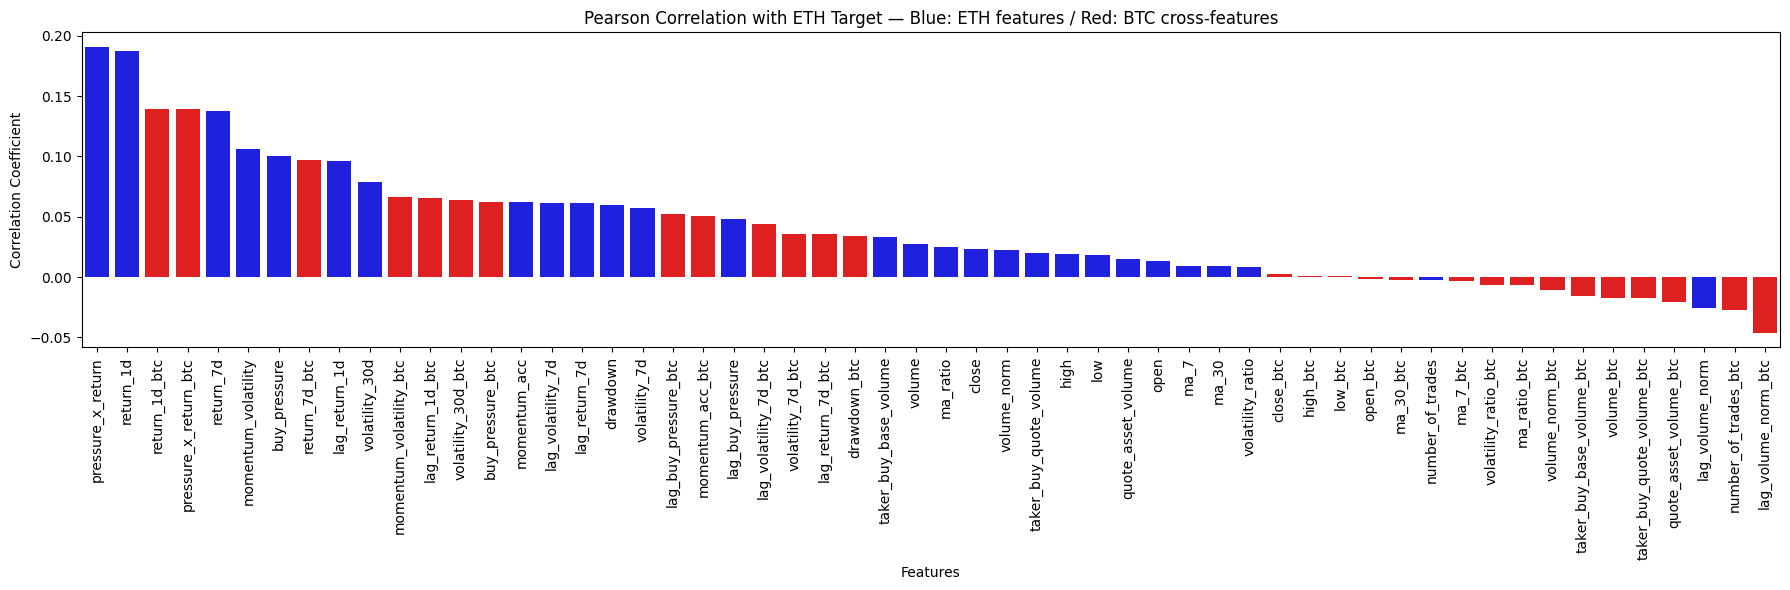

In [8]:
# Define cross-asset columns (BTC features)
cross_cols = [c for c in df_merged.columns if c.endswith("_btc")]

corrs_pearson = (
    df_merged
    .corr(method="pearson", numeric_only=True)["target"]
    .sort_values(ascending=False)
    .drop("target")
)

colors = ["red" if col in cross_cols else "blue" for col in corrs_pearson.index]

plt.figure(figsize=(18, 6))
sns.barplot(x=corrs_pearson.index, y=corrs_pearson.values,
            hue=corrs_pearson.index, palette=dict(zip(corrs_pearson.index, colors)), legend=False)
plt.xticks(rotation=90)
plt.title("Pearson Correlation with ETH Target — Blue: ETH features / Red: BTC cross-features")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

**Observations:**
- Pearson correlation with the ETH crash target is generally weak for both ETH and BTC features, consistent with the non-linear nature of crash events.
- Among BTC cross-features (red bars), **`pressure_x_return_btc`**, **`return_1d_btc`**, and **`return_7d_btc`** show the highest absolute Pearson values.
- Raw price columns (`open_btc`, `close_btc`, `high_btc`, `low_btc`) show near-zero Pearson correlation with the ETH crash target, as expected for unscaled absolute levels.
- Overall, BTC Pearson signals for ETH crash prediction are weaker than the equivalent ETH signals for BTC crash prediction (notebook 06), suggesting some directional asymmetry.

**Conclusion:**
Pearson correlation confirms that short-term BTC return and pressure features carry some linear signal for ETH crashes, but the overall signal is limited. Spearman and MI are needed to complete the picture.

**Spearman Correlation with Target**

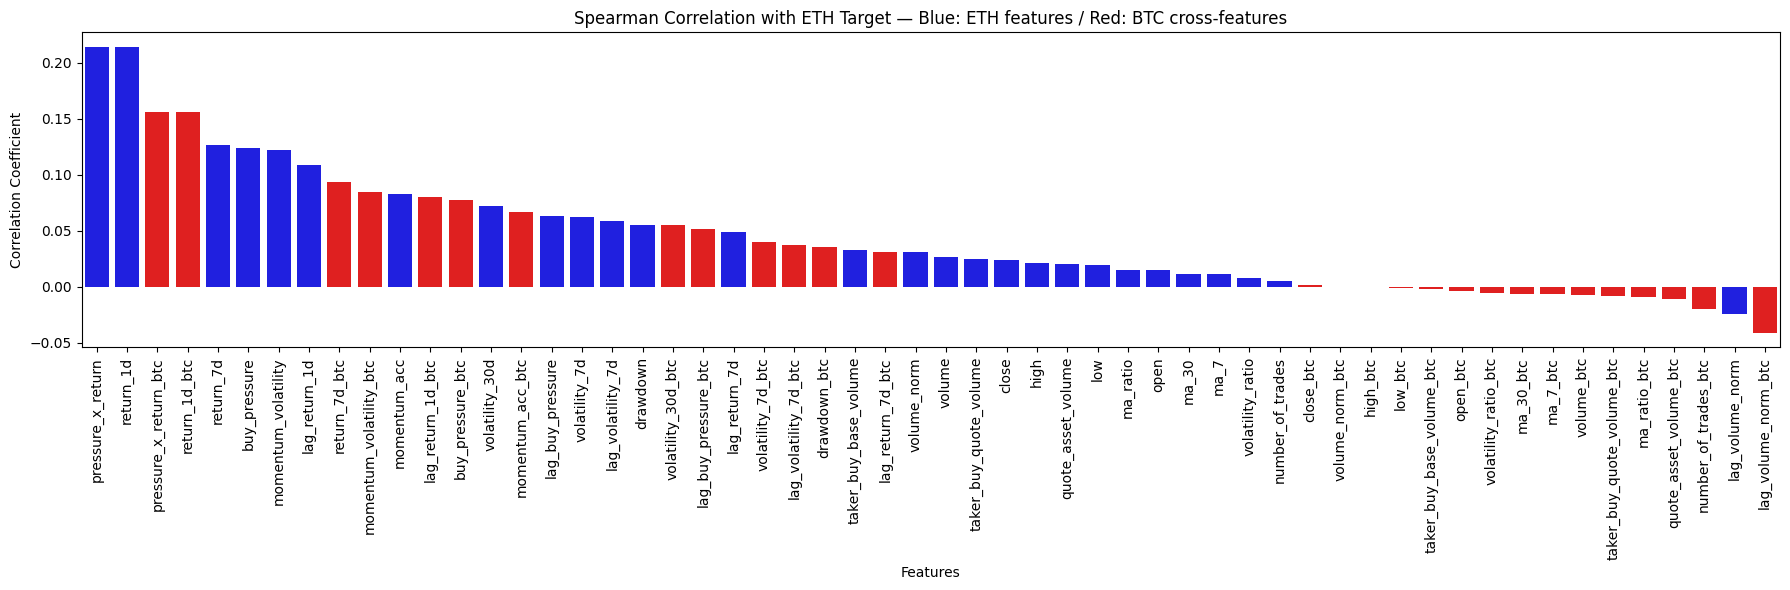

In [9]:
corrs_spearman = (
    df_merged
    .corr(method="spearman", numeric_only=True)["target"]
    .sort_values(ascending=False)
    .drop("target")
)
colors = ["red" if col in cross_cols else "blue" for col in corrs_spearman.index]

plt.figure(figsize=(18, 6))
sns.barplot(x=corrs_spearman.index, y=corrs_spearman.values,
            hue=corrs_spearman.index, palette=dict(zip(corrs_spearman.index, colors)), legend=False)
plt.xticks(rotation=90)
plt.title("Spearman Correlation with ETH Target — Blue: ETH features / Red: BTC cross-features")
plt.ylabel("Correlation Coefficient")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

**Observations:**
- Spearman correlation reveals a similar pattern to Pearson: **`pressure_x_return_btc`** and **`return_1d_btc`** are the strongest BTC cross-features for ETH crash prediction.
- Return and momentum features dominate; volume-based and price-level BTC features (`ma_7_btc`, `ma_30_btc`, `open_btc`, `close_btc`) show near-zero Spearman correlation.
- The signal is generally weaker than what ETH features provide for BTC prediction (notebook 06) — confirming an asymmetry: BTC crashes are more strongly anticipated by ETH dynamics than the reverse.

**Conclusion:**
A subset of BTC market features (return, momentum, buy pressure) carry genuine monotonic signal for ETH crash prediction. Price-level and moving average BTC features add little, and will likely score below the combined threshold.

**Mutual Information with Target**

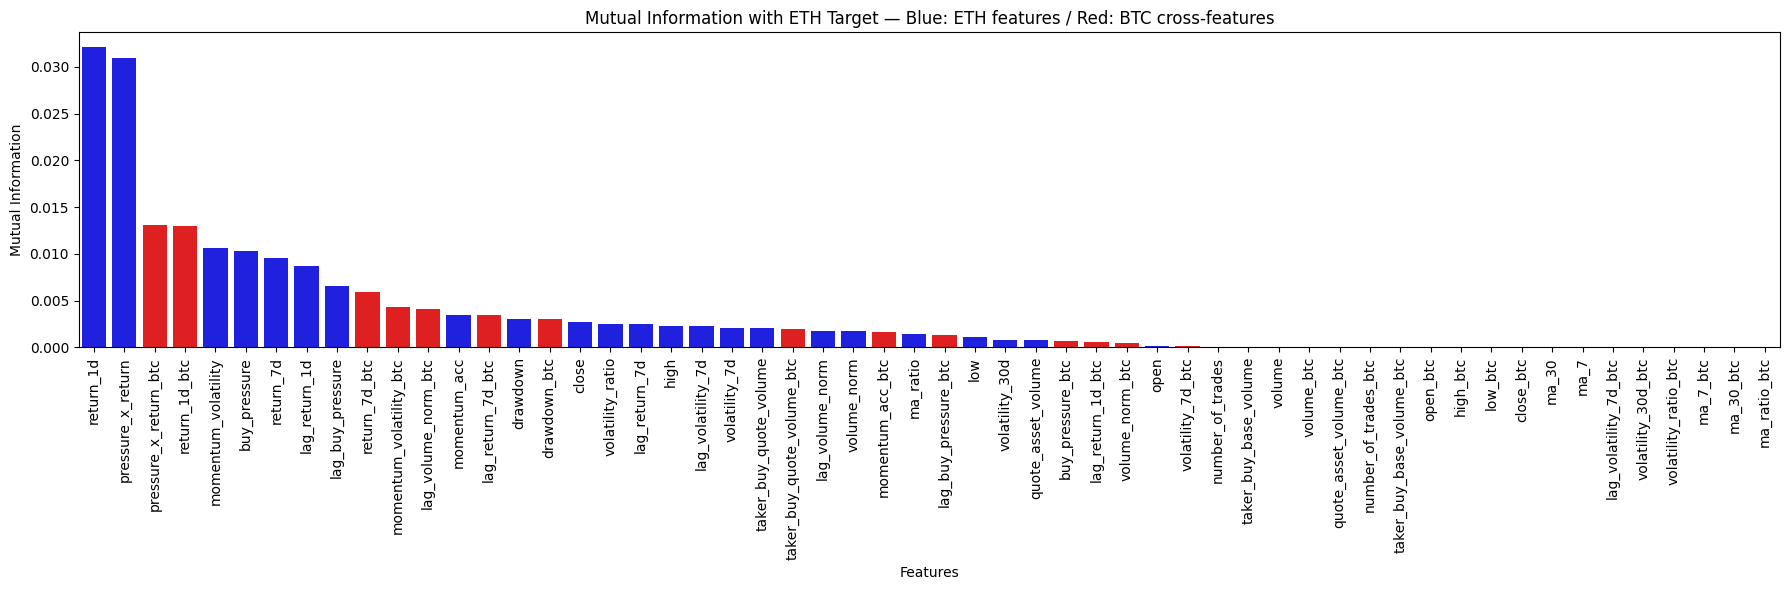

return_1d                     0.032083
pressure_x_return             0.030987
pressure_x_return_btc         0.013085
return_1d_btc                 0.012969
momentum_volatility           0.010652
buy_pressure                  0.010304
return_7d                     0.009518
lag_return_1d                 0.008657
lag_buy_pressure              0.006560
return_7d_btc                 0.005936
momentum_volatility_btc       0.004339
lag_volume_norm_btc           0.004100
momentum_acc                  0.003433
lag_return_7d_btc             0.003419
drawdown                      0.003041
drawdown_btc                  0.003034
close                         0.002748
volatility_ratio              0.002489
lag_return_7d                 0.002452
high                          0.002265
lag_volatility_7d             0.002233
volatility_7d                 0.002090
taker_buy_quote_volume        0.002030
taker_buy_quote_volume_btc    0.001963
lag_volume_norm               0.001782
volume_norm              

In [10]:
X = df_merged.drop(columns=["target"])
y = df_merged["target"].astype(int)  # ETH target is bool — cast to int for MI

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

mutual_info = mutual_info_classif(X_scaled, y, discrete_features=False, n_neighbors=5, random_state=42)
mutual_info_series = pd.Series(mutual_info, index=X.columns).sort_values(ascending=False)

colors_mi = ["red" if col in cross_cols else "blue" for col in mutual_info_series.index]

plt.figure(figsize=(18, 6))
sns.barplot(x=mutual_info_series.index, y=mutual_info_series.values,
            hue=mutual_info_series.index, palette=dict(zip(mutual_info_series.index, colors_mi)), legend=False)
plt.xticks(rotation=90)
plt.title("Mutual Information with ETH Target — Blue: ETH features / Red: BTC cross-features")
plt.ylabel("Mutual Information")
plt.xlabel("Features")
plt.tight_layout()
plt.show()

mutual_info_series

**Observations:**
- MI values for ETH crash prediction are notably low overall. The top ETH feature by MI is **`return_1d`** (0.032), and the top BTC cross-feature is **`pressure_x_return_btc`** (0.013).
- Many BTC cross-features show **MI = 0.000** for the ETH target (`open_btc`, `close_btc`, `high_btc`, `low_btc`, `ma_7_btc`, `ma_30_btc`, `ma_ratio_btc`, `volume_btc`, `quote_asset_volume_btc`, `number_of_trades_btc`, `taker_buy_base_volume_btc`). These features carry no detectable non-linear information about ETH crashes.
- The low MI across the board (vs. notebook 06 where top MI reached 0.154) reflects that ETH crash events are harder to predict from cross-asset dynamics alone.
- The combined score will be primarily driven by Spearman for features that have near-zero MI.

**Conclusion:**
ETH crashes exhibit weaker non-linear dependency on BTC cross-features than BTC crashes do on ETH cross-features. Feature selection will rely more heavily on the Spearman component of the combined score.

**Combined Score — BTC Cross-Feature Ranking**

To select BTC cross-features in a principled and consistent way with notebooks 04 and 05, a **combined score** is computed for each BTC feature:

$$\text{score} = \frac{|\rho_{\text{Spearman}}|}{\max(|\rho_{\text{Spearman}}|)} + \frac{\text{MI}}{\max(\text{MI})}$$

- Each term is **normalized to [0, 1]** against the maximum across *all features* (ETH + BTC), so the scale reflects how a BTC feature compares to the strongest signal in the dataset.
- The combined score ranges from **0 to 2**: 2 means the feature is best-in-class on both metrics simultaneously.
- The threshold **0.10** is used consistently with notebooks 04 and 05.

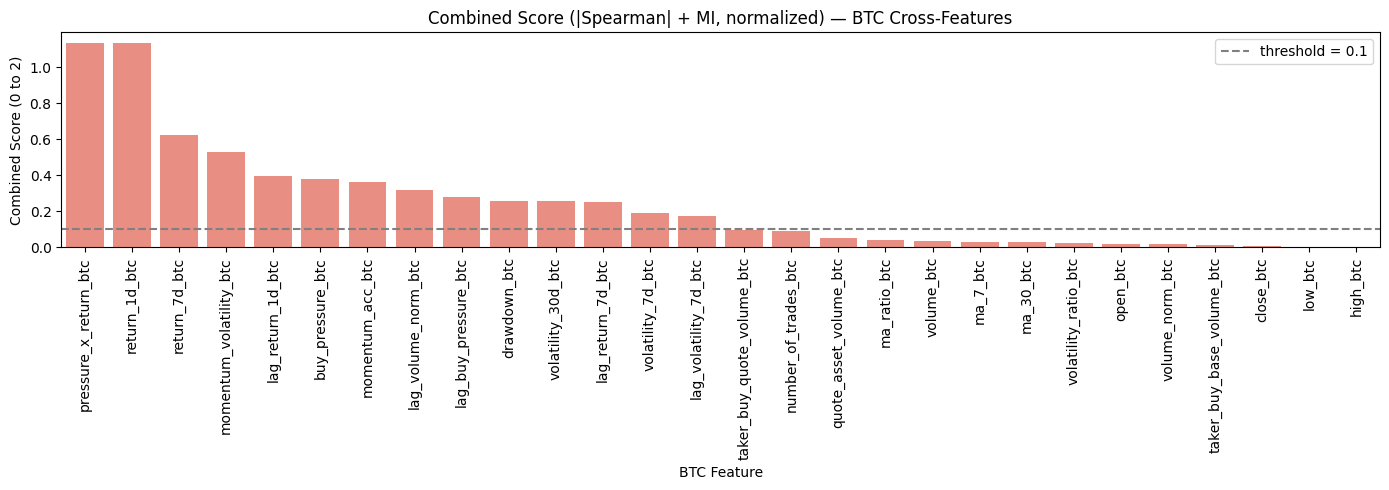

pressure_x_return_btc         1.136822
return_1d_btc                 1.132173
return_7d_btc                 0.621304
momentum_volatility_btc       0.528191
lag_return_1d_btc             0.393621
buy_pressure_btc              0.380549
momentum_acc_btc              0.364258
lag_volume_norm_btc           0.320485
lag_buy_pressure_btc          0.280071
drawdown_btc                  0.259573
volatility_30d_btc            0.256048
lag_return_7d_btc             0.252305
volatility_7d_btc             0.188460
lag_volatility_7d_btc         0.172171
taker_buy_quote_volume_btc    0.098153
number_of_trades_btc          0.092691
quote_asset_volume_btc        0.052350
ma_ratio_btc                  0.040892
volume_btc                    0.035940
ma_7_btc                      0.030626
ma_30_btc                     0.028755
volatility_ratio_btc          0.025012
open_btc                      0.018365
volume_norm_btc               0.016651
taker_buy_base_volume_btc     0.010924
close_btc                

In [11]:
cross_score = (
    corrs_spearman.abs() / corrs_spearman.abs().max()
    + mutual_info_series / mutual_info_series.max()
)[cross_cols].sort_values(ascending=False)

CROSS_SCORE_THRESHOLD = 0.10

plt.figure(figsize=(14, 5))
sns.barplot(x=cross_score.index, y=cross_score.values, color="salmon")
plt.axhline(y=CROSS_SCORE_THRESHOLD, color="gray", linestyle="--", linewidth=1.5,
            label=f"threshold = {CROSS_SCORE_THRESHOLD}")
plt.xticks(rotation=90)
plt.title("Combined Score (|Spearman| + MI, normalized) — BTC Cross-Features")
plt.ylabel("Combined Score (0 to 2)")
plt.xlabel("BTC Feature")
plt.legend()
plt.tight_layout()
plt.show()

cross_score

**Observations:**
- Combined scores range from **1.137** (`pressure_x_return_btc`) down to **0.003** (`high_btc`).
- **14 out of 28 BTC features exceed the 0.10 threshold.** A clear natural gap exists between `lag_volatility_7d_btc` (0.172, last keeper) and `taker_buy_quote_volume_btc` (0.098, first drop).
- Top tier (score > 0.5): **`pressure_x_return_btc`** (1.137), **`return_1d_btc`** (1.132), **`return_7d_btc`** (0.621), **`momentum_volatility_btc`** (0.528) — driven by both Spearman and MI.
- Mid tier (0.10–0.5): `lag_return_1d_btc`, `buy_pressure_btc`, `momentum_acc_btc`, `lag_volume_norm_btc`, `lag_buy_pressure_btc`, `drawdown_btc`, `volatility_30d_btc`, `lag_return_7d_btc`, `volatility_7d_btc`, `lag_volatility_7d_btc` — these clear the bar mainly through Spearman since MI is near zero.
- Features dropped (score < 0.10): raw prices (`open_btc`, `close_btc`, `high_btc`, `low_btc`), moving averages (`ma_7_btc`, `ma_30_btc`, `ma_ratio_btc`), and volume-level columns — none carry signal for ETH crashes.

**Conclusion:**
The threshold of 0.10 is validated by a natural gap in the score distribution. BTC cross-features that are informative for ETH crash prediction are exactly those reflecting short-term dynamics (returns, momentum, volatility, buy pressure), not raw price levels or long-term averages.

**Redundancy Check — BTC Cross-Features vs. ETH Features**

Before finalising the selection, cross-features that are **highly correlated with existing ETH features** are dropped: they would be redundant and inflate the feature count without adding new information.

Threshold: **0.9** — consistent with the within-asset redundancy filter used in notebook 03.

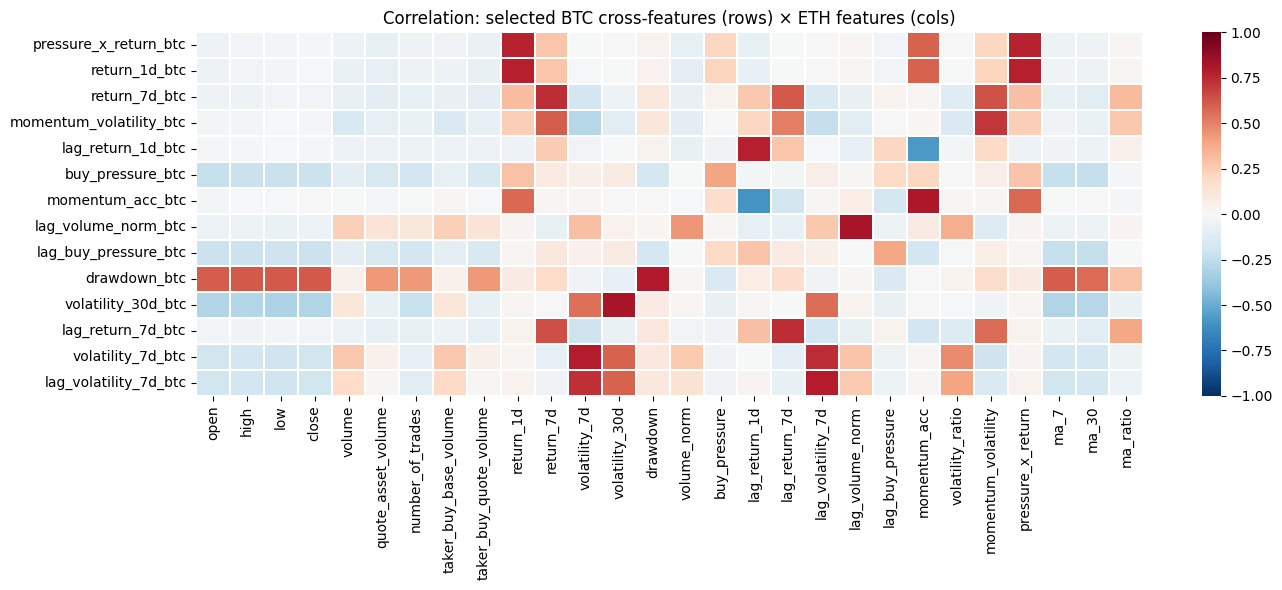

Candidates after combined score ≥ 0.1: 14
Redundant (max |corr| > 0.9): []
Kept after redundancy filter: ['pressure_x_return_btc', 'return_1d_btc', 'return_7d_btc', 'momentum_volatility_btc', 'lag_return_1d_btc', 'buy_pressure_btc', 'momentum_acc_btc', 'lag_volume_norm_btc', 'lag_buy_pressure_btc', 'drawdown_btc', 'volatility_30d_btc', 'lag_return_7d_btc', 'volatility_7d_btc', 'lag_volatility_7d_btc']


In [12]:
REDUNDANCY_THRESHOLD = 0.9

# Candidates: BTC features that pass the combined score threshold
candidates = cross_score[cross_score >= CROSS_SCORE_THRESHOLD].index.tolist()

# ETH features already in the model
eth_base_cols = [c for c in df_merged.columns if not c.endswith("_btc") and c != "target"]

# Correlation matrix between candidates and ETH features
corr_cross = df_merged[eth_base_cols + candidates].corr(numeric_only=True).loc[candidates, eth_base_cols]

# Heatmap
plt.figure(figsize=(max(12, len(eth_base_cols) * 0.5), max(6, len(candidates) * 0.4)))
sns.heatmap(
    corr_cross,
    annot=False,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
)
plt.title("Correlation: selected BTC cross-features (rows) × ETH features (cols)")
plt.tight_layout()
plt.show()

# Drop BTC features with max absolute correlation > threshold with any ETH feature
redundant = [f for f in candidates if corr_cross.loc[f].abs().max() > REDUNDANCY_THRESHOLD]
non_redundant = [f for f in candidates if f not in redundant]

print(f"Candidates after combined score ≥ {CROSS_SCORE_THRESHOLD}: {len(candidates)}")
print(f"Redundant (max |corr| > {REDUNDANCY_THRESHOLD}): {redundant}")
print(f"Kept after redundancy filter: {non_redundant}")

### 5. Final Dataset for Modeling

In [13]:
# Re-merge cleanly
btc_renamed2 = df_btc.rename(columns={c: f"{c}_btc" for c in df_btc.columns if c != "open_time"})
df_eth_btc = pd.merge(df_eth, btc_renamed2, on="open_time", how="inner")
df_eth_btc.drop(columns=["target_btc", "open_time"], inplace=True)
print(f"Final dataset: {df_eth_btc.shape[0]} rows, {df_eth_btc.shape[1]} columns")
df_eth_btc.columns

Final dataset: 3114 rows, 57 columns


Index(['open', 'high', 'low', 'close', 'volume', 'quote_asset_volume',
       'number_of_trades', 'taker_buy_base_volume', 'taker_buy_quote_volume',
       'return_1d', 'return_7d', 'volatility_7d', 'volatility_30d', 'drawdown',
       'volume_norm', 'buy_pressure', 'lag_return_1d', 'lag_return_7d',
       'lag_volatility_7d', 'lag_volume_norm', 'lag_buy_pressure',
       'momentum_acc', 'volatility_ratio', 'momentum_volatility',
       'pressure_x_return', 'ma_7', 'ma_30', 'ma_ratio', 'target', 'open_btc',
       'high_btc', 'low_btc', 'close_btc', 'volume_btc',
       'quote_asset_volume_btc', 'number_of_trades_btc',
       'taker_buy_base_volume_btc', 'taker_buy_quote_volume_btc',
       'return_1d_btc', 'return_7d_btc', 'volatility_7d_btc',
       'volatility_30d_btc', 'drawdown_btc', 'volume_norm_btc',
       'buy_pressure_btc', 'lag_return_1d_btc', 'lag_return_7d_btc',
       'lag_volatility_7d_btc', 'lag_volume_norm_btc', 'lag_buy_pressure_btc',
       'momentum_acc_btc', 'volat

**Feature Selection**

**ETH market features** are taken from the selection established in notebook 03 (ETH EDA), validated on 3 114 rows with a correlation-based redundancy filter (threshold 0.9).

**BTC cross-features** go through a **two-step selection**:
1. **Combined score ≥ 0.10** (|Spearman| + MI, normalized) — 14 out of 28 BTC features pass (natural gap between score 0.172 and 0.098)
2. **Redundancy filter (|corr| > 0.9)** — no BTC feature is highly correlated with any ETH feature already in the model

**Result:** 17 ETH features + 14 BTC cross-features = **31 total features** on **3 114 rows**.

In [14]:
# ETH market features from notebook 03
ETH_FEATURES = [
    "return_1d", "return_7d",
    "volatility_7d", "volatility_30d",
    "buy_pressure",
    "drawdown",
    "ma_ratio",
    "lag_return_1d", "lag_return_7d",
    "lag_volatility_7d",
    "lag_buy_pressure",
    "lag_volume_norm",
    "momentum_acc",
    "momentum_volatility",
    "volume",
    "number_of_trades",
    "quote_asset_volume",
]

# BTC cross-features: combined score >= threshold AND not redundant with ETH features
BTC_CROSS_FEATURES = non_redundant

SELECTED_FEATURES = ETH_FEATURES + BTC_CROSS_FEATURES
TARGET = "target"

print(f"ETH features: {len(ETH_FEATURES)}")
print(f"BTC cross-features selected (after redundancy filter): {len(BTC_CROSS_FEATURES)}")
print(f"Total features: {len(SELECTED_FEATURES)}")
print(f"BTC features kept: {BTC_CROSS_FEATURES}")

df_eth_btc = df_eth_btc[SELECTED_FEATURES + [TARGET]]
df_eth_btc.head()

ETH features: 17
BTC cross-features selected (after redundancy filter): 14
Total features: 31
BTC features kept: ['pressure_x_return_btc', 'return_1d_btc', 'return_7d_btc', 'momentum_volatility_btc', 'lag_return_1d_btc', 'buy_pressure_btc', 'momentum_acc_btc', 'lag_volume_norm_btc', 'lag_buy_pressure_btc', 'drawdown_btc', 'volatility_30d_btc', 'lag_return_7d_btc', 'volatility_7d_btc', 'lag_volatility_7d_btc']


,return_1d,return_7d,volatility_7d,volatility_30d,buy_pressure,drawdown,ma_ratio,lag_return_1d,lag_return_7d,lag_volatility_7d,...,buy_pressure_btc,momentum_acc_btc,lag_volume_norm_btc,lag_buy_pressure_btc,drawdown_btc,volatility_30d_btc,lag_return_7d_btc,volatility_7d_btc,lag_volatility_7d_btc,target
0,-0.014585,-0.159837,0.116971,0.077232,0.373150,-0.358209,0.850311,0.175596,-0.164989,0.116960,...,0.481585,-0.156191,2.390714,0.490700,-0.231640,0.060268,-0.136079,0.104128,0.103904,False
1,0.033051,-0.122487,0.118611,0.077380,0.312492,-0.336997,0.837263,-0.014585,-0.159837,0.116971,...,0.401559,-0.008068,1.544177,0.481585,-0.234734,0.059834,-0.127702,0.103943,0.104128,False
2,0.143739,-0.009183,0.132689,0.081752,0.567790,-0.241698,0.835699,0.033051,-0.122487,0.118611,...,0.405472,0.094573,0.828846,0.401559,-0.165443,0.062149,-0.104199,0.110665,0.103943,True
3,-0.035883,-0.033882,0.133563,0.081930,0.422389,-0.268908,0.832508,0.143739,-0.009183,0.132689,...,0.285173,-0.121518,1.219432,0.405472,-0.191290,0.062376,-0.041217,0.111239,0.110665,False
4,-0.007042,0.018381,0.131049,0.080559,0.534286,-0.274057,0.838497,-0.035883,-0.033882,0.133563,...,0.548281,0.028404,1.050238,0.285173,-0.193367,0.062290,-0.060926,0.109144,0.111239,False


**Observations:**
- The final dataset contains **3 114 rows** and **31 feature columns** + 1 target column.
- **17 ETH market features**: core price, return, volatility, volume, and momentum indicators from notebook 03.
- **14 BTC cross-features**: only return, momentum, volatility, and buy pressure-based features — raw prices and long-term moving averages are excluded.
- No BTC cross-feature is redundant with any ETH feature at the 0.9 threshold, confirming the cross-asset features add orthogonal information.
- The dataset is notably smaller in feature count than the BTC+ETH model (31 vs. 45), reflecting the weaker and more selective cross-asset signal from BTC to ETH.

**Conclusion:**
The ETH+BTC cross-asset dataset retains only the most informative BTC features, avoiding noise from raw price levels and moving averages. The final feature set is compact (31 features) and non-redundant.

### **General Conclusion — EDA ETH Price × BTC Cross-Features**

#### **Key Findings**

| Metric | Top BTC cross-feature | Value |
|---|---|---|
| Mutual Information | `pressure_x_return_btc` | 0.013 |
| Combined score | `pressure_x_return_btc` | 1.137 |
| Features above threshold (0.10) | — | 14 / 28 |
| Redundant with ETH features | — | 0 / 14 |

1. **BTC cross-signal for ETH is weaker and more selective than the reverse**: only 14/28 BTC features pass the combined score threshold (vs. all 28/28 ETH features in notebook 06). This confirms an asymmetry — ETH market dynamics broadly mirror BTC, but BTC alone is less sufficient to anticipate ETH-specific crashes.
2. **Near-zero MI for many BTC features**: raw price levels, moving averages, and volume aggregates show MI = 0.000 with the ETH crash target. Feature selection is therefore driven primarily by the Spearman component for this subset.
3. **Short-term dynamics are the relevant BTC signal**: `pressure_x_return_btc`, `return_1d_btc`, `return_7d_btc`, and `momentum_volatility_btc` lead the ranking — all reflect short-term price behaviour rather than trend or level.
4. **No redundancy with ETH features**: the redundancy check at 0.9 absolute correlation removes zero features, confirming BTC and ETH engineered features are sufficiently distinct.

#### **Feature Selection Methodology**

| Feature type | Count | Selection criterion |
|---|---|---|
| ETH market features | 17 | Correlation-based redundancy filter from notebook 03 (threshold 0.9) |
| BTC cross-features | 14 | Combined score (|Spearman| + MI, normalized) ≥ **0.10** + no redundancy with ETH (|corr| ≤ 0.9) |
| **Total** | **31** | |

#### **Final Feature Set**

**ETH features (17):**
`return_1d`, `return_7d`, `volatility_7d`, `volatility_30d`, `buy_pressure`, `drawdown`, `ma_ratio`, `lag_return_1d`, `lag_return_7d`, `lag_volatility_7d`, `lag_buy_pressure`, `lag_volume_norm`, `momentum_acc`, `momentum_volatility`, `volume`, `number_of_trades`, `quote_asset_volume`

**BTC cross-features (14):**
`pressure_x_return_btc`, `return_1d_btc`, `return_7d_btc`, `momentum_volatility_btc`, `lag_return_1d_btc`, `buy_pressure_btc`, `momentum_acc_btc`, `lag_volume_norm_btc`, `lag_buy_pressure_btc`, `drawdown_btc`, `volatility_30d_btc`, `lag_return_7d_btc`, `volatility_7d_btc`, `lag_volatility_7d_btc`

#### **Conclusion**
BTC cross-features provide targeted but selective complementary signal for ETH crash prediction. Only 14 BTC features — all reflecting short-term market dynamics — clear the 0.10 threshold and are free of redundancy with ETH features. The ETH+BTC model (31 features, 3 114 rows) is more compact than the BTC+ETH model (45 features) due to the weaker and more directional cross-asset signal from BTC to ETH.